# 03 — Benchmark Models

Part 3: five simple benchmarks (mean, naive, seasonal naive daily/weekly, drift), evaluated under the rolling 14-day walk-forward design (see `report.md` Section 4 for why rolling, not single-shot). This notebook runs the benchmarks live — they're cheap, no fitting involved.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
from IPython.display import Image, display

from appliance_energy.config import PROCESSED_DIR, TARGET, TEST_STEPS, DAILY_PERIOD, WEEKLY_PERIOD
from appliance_energy.models.benchmarks import generate_rolling_benchmarks
from appliance_energy.evaluation import evaluate_all

df = pd.read_csv(PROCESSED_DIR / 'appliance_hourly.csv', index_col='date', parse_dates=True).asfreq('h')
y = df[TARGET]
train, test = y.iloc[:-TEST_STEPS], y.iloc[-TEST_STEPS:]
print(f'Train: {len(train)} obs, Test: {len(test)} obs')

Train: 2954 obs, Test: 336 obs


In [2]:
forecasts = generate_rolling_benchmarks(train, test, block_size=DAILY_PERIOD,
                                         daily_period=DAILY_PERIOD, weekly_period=WEEKLY_PERIOD)
comparison = evaluate_all(test, forecasts, train)
comparison

,model,MAE,RMSE,MASE,Bias
0,seasonal_naive_weekly,43.457341,81.408880,1.077253,-13.159722
1,seasonal_naive_daily,48.308532,85.564719,1.197508,1.750992
2,mean,50.258092,74.938304,1.245835,-3.286762
3,naive,85.550595,110.389709,2.120691,50.977183
4,drift,85.802089,110.679190,2.126926,51.367922


`seasonal_naive_weekly` is clearly the strongest benchmark — see notebook 07 / the report for why this matters (day-of-week carries real information, not just time-of-day).

## Forecast plot

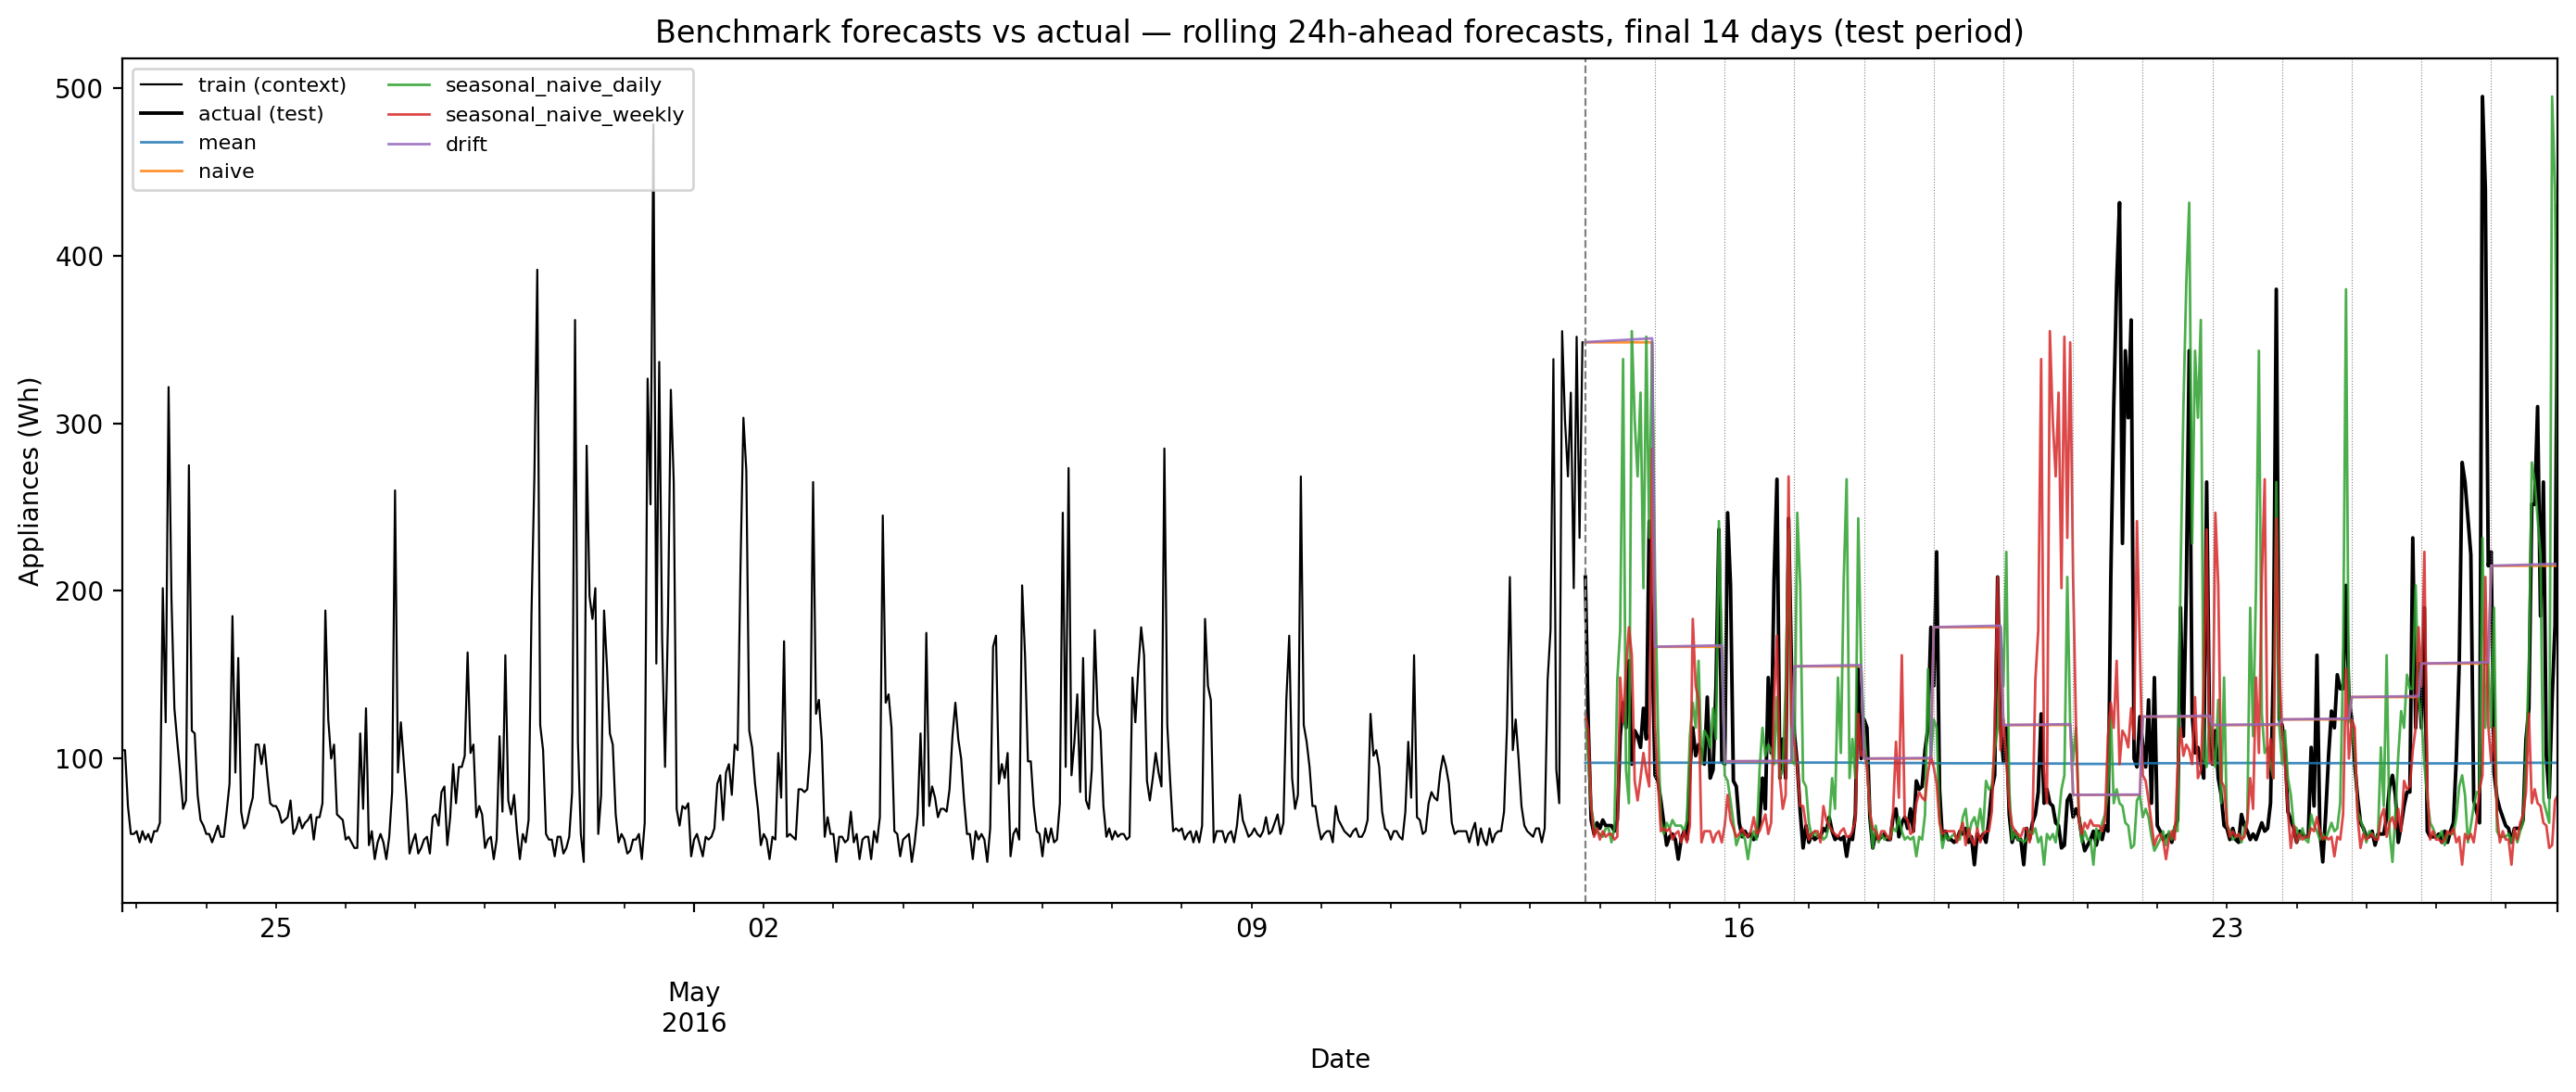

In [3]:
display(Image(filename='../outputs/figures/forecast_comparison.png'))